In [1]:
import zipfile

zip_path = "/content/part_2_cnn_computer_vision.zip"

extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
dataset_path = "/content/part_2_cnn_computer_vision/images"

In [4]:
classes = os.listdir(dataset_path)

print(classes)

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [6]:
classes = [folder for folder in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, folder))]

for category in classes:

    path = os.path.join(dataset_path, category)

    print(category, ":", len(os.listdir(path)))

normal : 120
stain : 120
dent : 120
scratch : 120


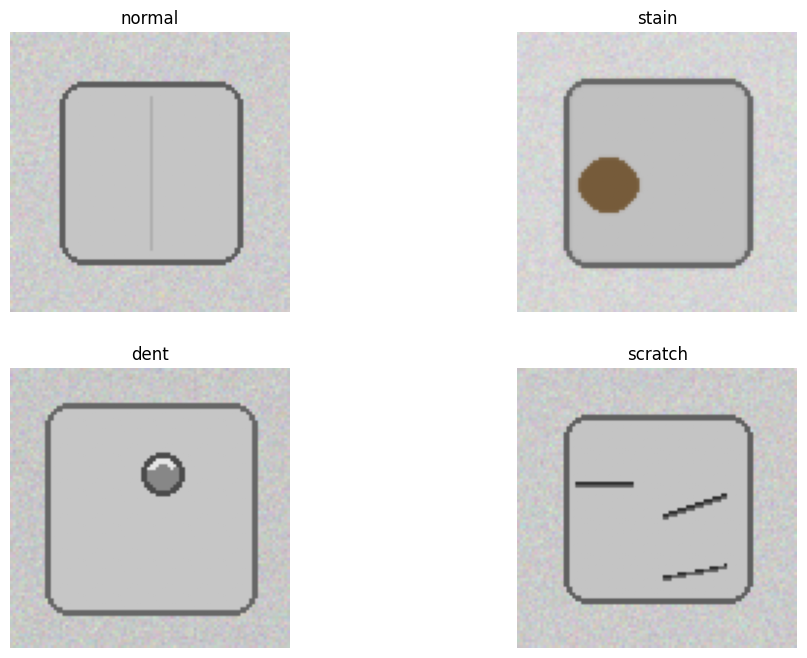

In [7]:
import matplotlib.image as mpimg

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    img_path = os.path.join(dataset_path, category,
                            os.listdir(os.path.join(dataset_path, category))[0])

    img = mpimg.imread(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(category)

    plt.axis('off')

plt.show()

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [9]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [10]:
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


In [11]:
model = Sequential()

In [12]:
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 929ms/step - accuracy: 0.2969 - loss: 1.9752 - val_accuracy: 0.3750 - val_loss: 1.3791
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 899ms/step - accuracy: 0.3073 - loss: 1.3545 - val_accuracy: 0.4271 - val_loss: 1.3054
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 883ms/step - accuracy: 0.5156 - loss: 1.1876 - val_accuracy: 0.6042 - val_loss: 1.0267
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 760ms/step - accuracy: 0.6458 - loss: 0.9443 - val_accuracy: 0.5208 - val_loss: 0.9438
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 894ms/step - accuracy: 0.7292 - loss: 0.7294 - val_accuracy: 0.6771 - val_loss: 0.6492
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 888ms/step - accuracy: 0.8203 - loss: 0.4995 - val_accuracy: 0.7292 - val_loss: 0.5222
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 873ms/step - accuracy: 0.8724 - loss: 0.3730 - val_accuracy: 0.8229 - val_loss: 0.4776
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 769ms/step - accuracy: 0.8594 - loss: 0.3560 - val_accura

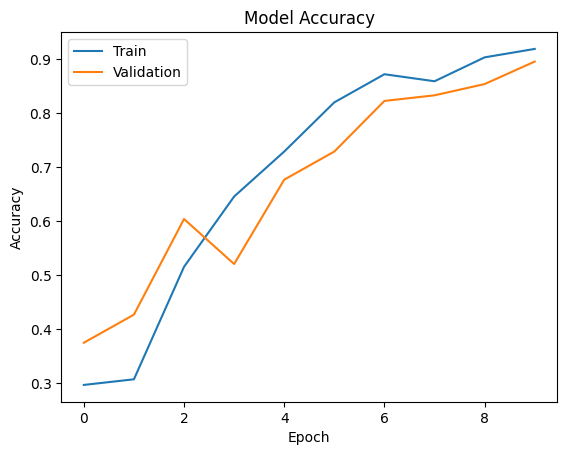

In [16]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

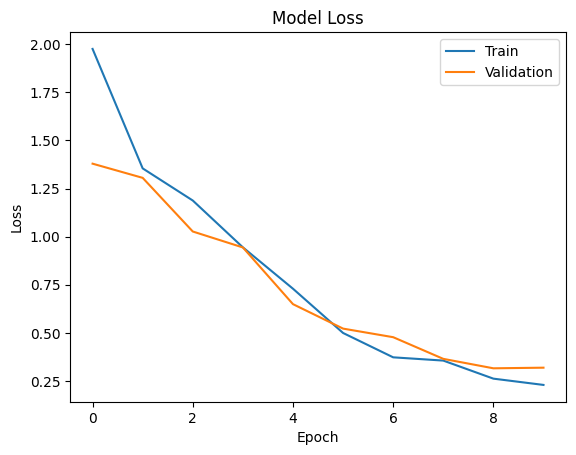

In [17]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [18]:
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step


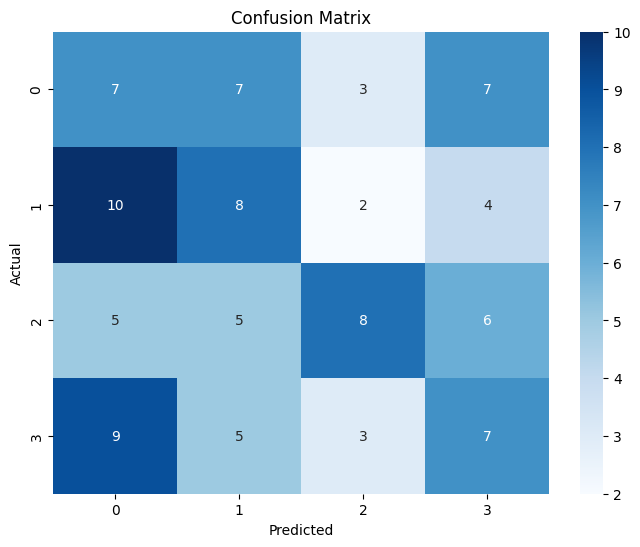

In [19]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [20]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
))

              precision    recall  f1-score   support

      normal       0.23      0.29      0.25        24
       stain       0.32      0.33      0.33        24
        dent       0.50      0.33      0.40        24
     scratch       0.29      0.29      0.29        24

    accuracy                           0.31        96
   macro avg       0.33      0.31      0.32        96
weighted avg       0.33      0.31      0.32        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Predicted Class: normal


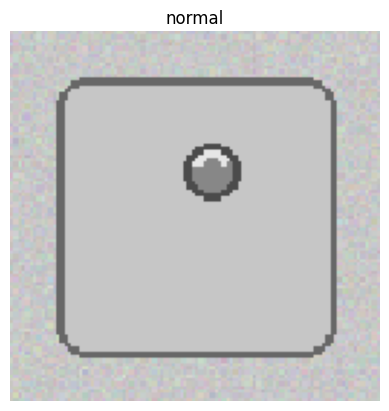

In [21]:
img_path = os.path.join(dataset_path,
                        "dent",
                        os.listdir(os.path.join(dataset_path, "dent"))[0])

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

plt.imshow(img)

plt.title(predicted_class)

plt.axis('off')

plt.show()

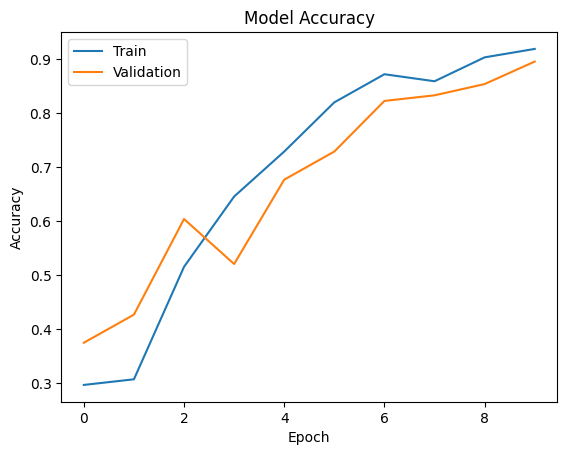

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")

plt.show()

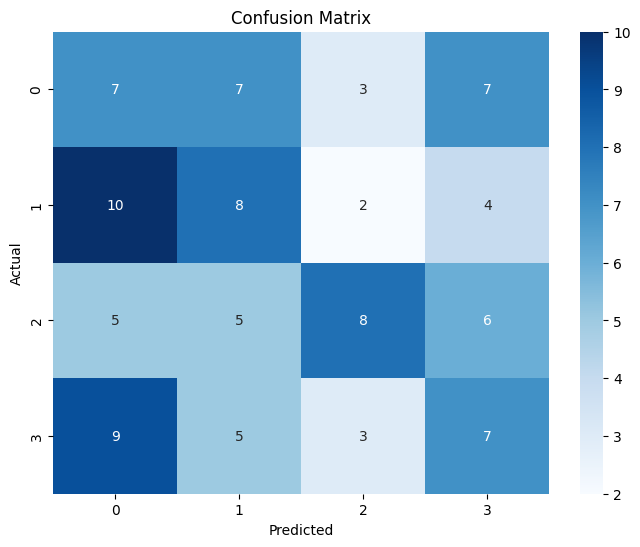

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted Class: normal


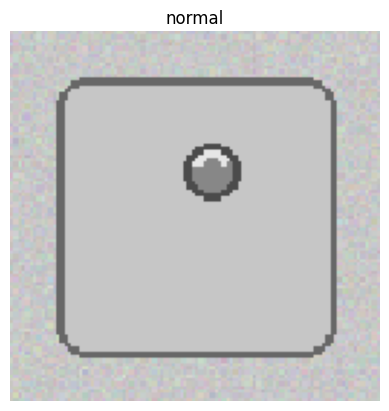

In [24]:
img_path = os.path.join(
    dataset_path,
    "dent",
    os.listdir(os.path.join(dataset_path, "dent"))[0]
)

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

plt.imshow(img)

plt.title(predicted_class)

plt.axis('off')

plt.savefig("prediction_outputs.png")

plt.show()

In [25]:
readme_content = """
# Part 2 - CNN Computer Vision Project

## Problem Type
This project is based on Image Classification using CNN.

## Dataset Exploration
- Multiple image classes
- Images categorized into different defect types
- Dataset analyzed for class distribution and sample images

## Image Preprocessing
- Resized images to 128x128
- Normalized pixel values
- Split dataset into training and validation sets

## CNN Architecture
The CNN model includes:
- Convolution layers
- ReLU activation
- MaxPooling layers
- Flatten layer
- Dense layers
- Softmax output layer

## Model Evaluation
- Training accuracy and validation accuracy calculated
- Confusion matrix generated
- Sample predictions performed

## CNN Concepts

### What is Convolution?
Convolution helps detect important patterns like edges, textures, and shapes from images.

### Why Pooling is Used?
Pooling reduces image dimensions and computational complexity.

### Why ReLU is Used?
ReLU introduces non-linearity and improves training speed.

### Why CNN is Better for Images?
CNN automatically extracts image features and performs better than traditional neural networks for image data.

## Business Use Case
This type of solution can be used in manufacturing industries for automatic defect detection and quality inspection.

## Technologies Used
- Python
- TensorFlow/Keras
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md file created successfully")

README.md file created successfully


In [26]:
requirements = """
tensorflow
numpy
pandas
matplotlib
seaborn
scikit-learn
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created")

requirements.txt created
